# Two Disks
Ok, great, now I want to simulate a different initial condition to compare the two models: I want two disks of the same radius barely touching each other as the initial condition. They could be centered at the same hight (i.e., row), and deplaced 

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from core import (
    SquareLattice,
    DiskSeed,
    DoubleDiskSeed,
    CellDrivenGrowth,
    EmptyDrivenGrowth,
    CultureSimulator,
)
from lib import (
    plot_population_curves,
    plot_snapshots,
    plot_birth_time,
    plot_cell_id,
    summarize_simulation,
)

In [4]:
tau = 1.0
t_final = 100.0
seed = 12345

lattice = SquareLattice(nrows=201, ncols=201, periodic=False)

# Two equal disks, same row, horizontally separated by 2 * radius
initializer = DoubleDiskSeed(
    radius=20,
    center_row=None,
    center_col_left=None,
    horizontal_separation=39,  # = 2 * radius
)

initial_state = initializer.generate(lattice)

simulator = CultureSimulator(lattice)

model_1 = CellDrivenGrowth(tau=tau)
model_2 = EmptyDrivenGrowth(tau=tau*2.0)

snapshot_times = [0.0, 10.0, 25.0, 50.0, 75.0, 100.0]

rng1 = np.random.default_rng(seed)
rng2 = np.random.default_rng(seed + 1)

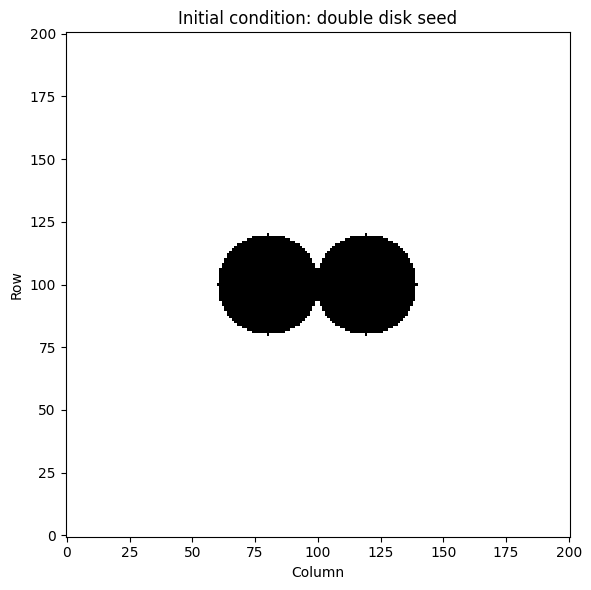

Initial number of occupied sites: 2512


In [5]:
# Just to inspect the initial condition
plt.figure(figsize=(6, 6))
plt.imshow(
    lattice.reshape_state(initial_state.occupancy).astype(int),
    origin="lower",
    interpolation="nearest",
    cmap="binary",
    vmin=0,
    vmax=1,
)
plt.title("Initial condition: double disk seed")
plt.xlabel("Column")
plt.ylabel("Row")
plt.tight_layout()
plt.show()

print("Initial number of occupied sites:", initial_state.n_cells)

In [6]:
result_1 = simulator.run(
    initial_state=initial_state,
    model=model_1,
    t_final=t_final,
    rng=rng1,
    snapshot_times=snapshot_times,
)

result_2 = simulator.run(
    initial_state=initial_state,
    model=model_2,
    t_final=t_final,
    rng=rng2,
    snapshot_times=snapshot_times,
)

In [7]:
summarize_simulation(result_1, "cell_driven")
print()
summarize_simulation(result_2, "empty_driven")

Model: cell_driven
Final time: 91.680417
Initial cells: 2512
Final cells: 40401
Number of events: 37889

Model: empty_driven
Final time: 97.242302
Initial cells: 2512
Final cells: 40401
Number of events: 37889


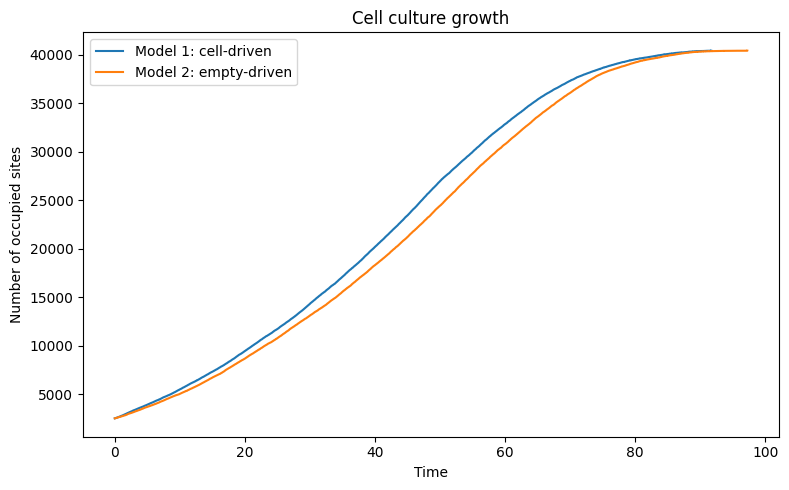

In [8]:
plot_population_curves(
    results=[result_1, result_2],
    labels=["Model 1: cell-driven", "Model 2: empty-driven"],
)

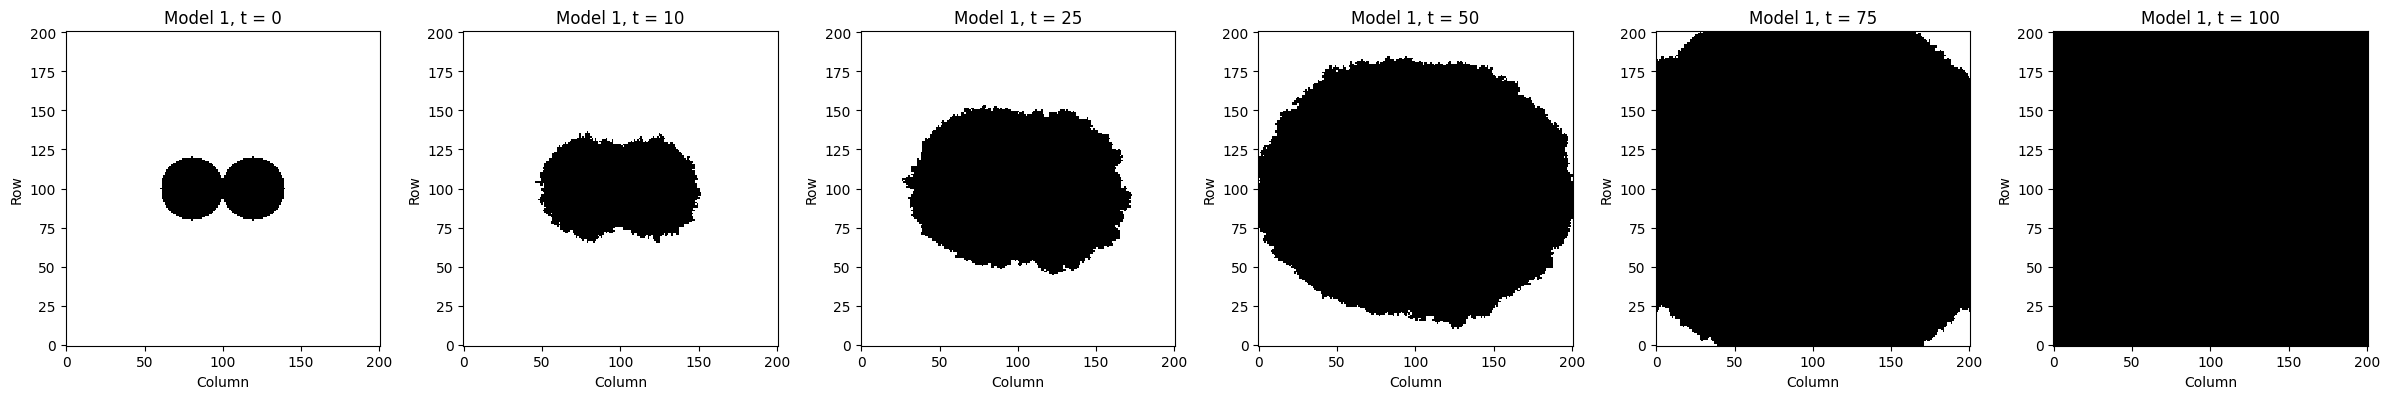

In [9]:
plot_snapshots(
    lattice=lattice,
    result=result_1,
    times_to_show=snapshot_times,
    title_prefix="Model 1, ",
)

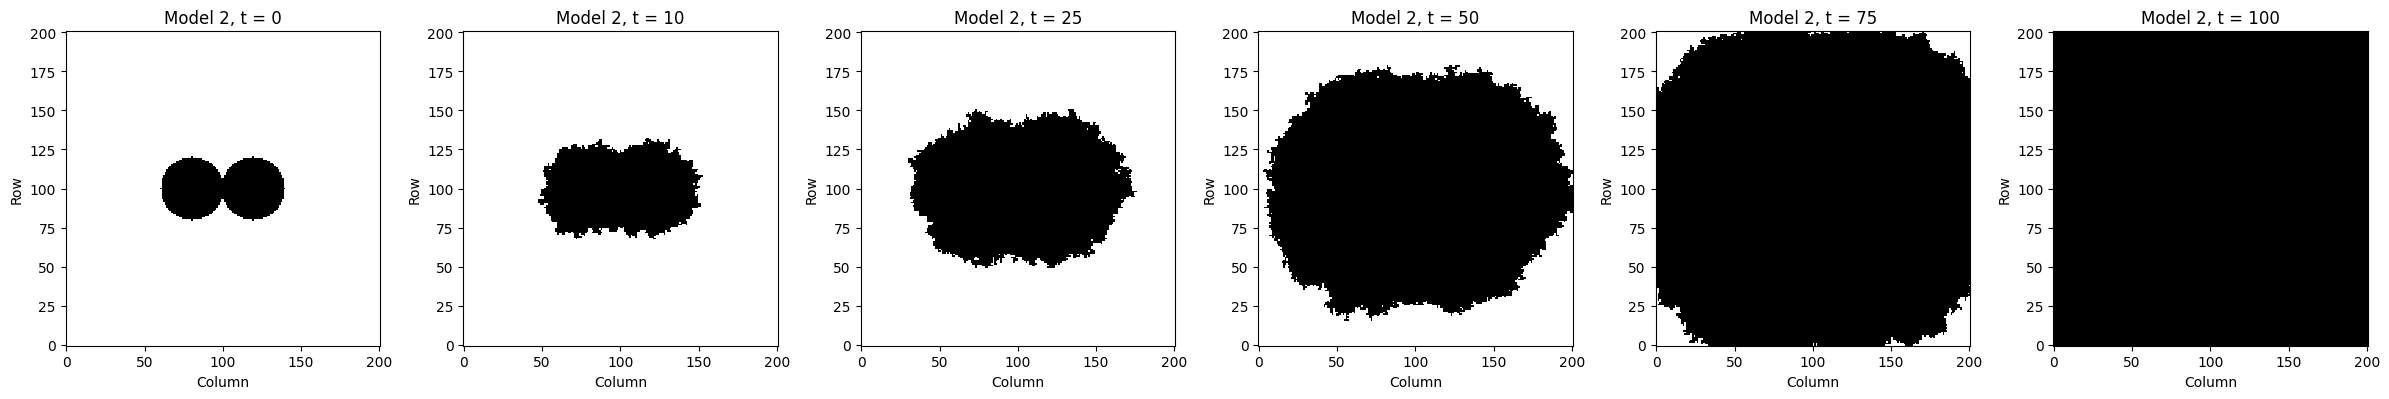

In [10]:
plot_snapshots(
    lattice=lattice,
    result=result_2,
    times_to_show=snapshot_times,
    title_prefix="Model 2, ",
)